# VAE Training — Option 4 Split + Memory Delta Features

Trains a **2-hidden-layer Variational Autoencoder** in pure NumPy on the new Option 4 preprocessed data.

**Pipeline recap:**
```
data/processed/windows_v4/X_train.npy  →  VAE trains here (normals only)
data/processed/windows_v4/X_val.npy    →  early stopping
```

**Architecture:** `INPUT → 64 → 32 → z(16) → 32 → 64 → INPUT`  
**INPUT_DIM** is read dynamically from `X_train.shape[1]` (set by PCA on 326-dim window)  
**Saved to:** `models/vae_v4.pkl`

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pickle, os, time

np.random.seed(42)

# ── Paths ──────────────────────────────────────────────────────────────
DATA_DIR   = r'c:\Users\jthar\Documents\Claude\Projects\module3\module3\data\processed\windows_v4'
MODEL_DIR  = r'c:\Users\jthar\Documents\Claude\Projects\module3\module3\models'
MODEL_PATH = os.path.join(MODEL_DIR, 'vae_v4.pkl')
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Hyperparameters ────────────────────────────────────────────────────
HIDDEN1    = 64
HIDDEN2    = 32
LATENT_DIM = 16
BETA       = 1.0      # standard VAE (was 0.5 — raised to force KL regularisation toward N(0,1))
KL_WARMUP  = 20       # epochs to ramp beta 0 -> BETA
EPOCHS     = 300      # increased from 150 — gives early stopping room to trigger
BATCH_SIZE = 1024
LR         = 1e-3
PATIENCE   = 20       # early stopping patience

print('Config ready.')
print(f'  Architecture : INPUT -> {HIDDEN1} -> {HIDDEN2} -> z({LATENT_DIM}) -> {HIDDEN2} -> {HIDDEN1} -> INPUT')
print(f'  KL warmup    : {KL_WARMUP} epochs  |  BETA = {BETA}  (standard VAE regularisation)')
print(f'  Training     : {EPOCHS} epochs max  |  batch={BATCH_SIZE}  |  LR={LR}  |  patience={PATIENCE}')

Config ready.
  Architecture : INPUT -> 64 -> 32 -> z(16) -> 32 -> 64 -> INPUT
  KL warmup    : 20 epochs  |  BETA = 1.0  (standard VAE regularisation)
  Training     : 300 epochs max  |  batch=1024  |  LR=0.001  |  patience=20


---
## Part 1 — Load Data

In [9]:
print('Loading preprocessed windows (Option 4 split + memory delta features) ...')
X_train = np.load(os.path.join(DATA_DIR, 'X_train.npy')).astype(np.float32)
X_val   = np.load(os.path.join(DATA_DIR, 'X_val.npy')).astype(np.float32)

INPUT_DIM = X_train.shape[1]   # set dynamically from PCA output

print(f'  X_train : {X_train.shape}  (all normal — VAE trains here)')
print(f'  X_val   : {X_val.shape}   (all normal — early stopping)')
print(f'  INPUT_DIM = {INPUT_DIM}  (PCA components from 326-dim window)')
print()
print(f'  X_train value range : [{X_train.min():.4f},  {X_train.max():.4f}]')
print(f'  X_train NaNs        : {np.isnan(X_train).sum()}  (must be 0)')
print(f'  X_val   NaNs        : {np.isnan(X_val).sum()}   (must be 0)')

Loading preprocessed windows (Option 4 split + memory delta features) ...
  X_train : (246594, 31)  (all normal — VAE trains here)
  X_val   : (27400, 31)   (all normal — early stopping)
  INPUT_DIM = 31  (PCA components from 326-dim window)

  X_train value range : [-16.8901,  25.7747]
  X_train NaNs        : 0  (must be 0)
  X_val   NaNs        : 0   (must be 0)


---
## Part 2 — VAE Class (Pure NumPy)

Manual forward pass, backpropagation, and Adam optimizer.  
No PyTorch, no TensorFlow — zero DLL dependencies.

**Why KL Warmup?**  
If we enforce the KL penalty from epoch 1, the encoder collapses — it sends everything to `z ~ N(0,1)` to minimize KL, ignoring reconstruction. Warmup gives the encoder time to first learn to reconstruct before being penalized for the latent space shape.

In [10]:
class NumpyVAE:
    """2-hidden-layer VAE in pure NumPy with Adam optimizer."""

    def __init__(self, input_dim, hidden1, hidden2, latent_dim, lr=1e-3):
        self.D, self.H1, self.H2, self.Z = input_dim, hidden1, hidden2, latent_dim
        self.lr = lr
        self._init_weights()
        self._init_adam()

    # ── Weight initialisation (He uniform) ──────────────────────────────
    def _init_weights(self):
        D, H1, H2, Z = self.D, self.H1, self.H2, self.Z
        s = lambda n: np.sqrt(2.0 / n)
        self.We1  = np.random.randn(D,  H1).astype(np.float32) * s(D)
        self.be1  = np.zeros(H1, dtype=np.float32)
        self.We2  = np.random.randn(H1, H2).astype(np.float32) * s(H1)
        self.be2  = np.zeros(H2, dtype=np.float32)
        self.Wmu  = np.random.randn(H2, Z).astype(np.float32)  * s(H2)
        self.bmu  = np.zeros(Z,  dtype=np.float32)
        self.Wlv  = np.random.randn(H2, Z).astype(np.float32)  * s(H2)
        self.blv  = np.zeros(Z,  dtype=np.float32)
        self.Wd1  = np.random.randn(Z,  H2).astype(np.float32) * s(Z)
        self.bd1  = np.zeros(H2, dtype=np.float32)
        self.Wd2  = np.random.randn(H2, H1).astype(np.float32) * s(H2)
        self.bd2  = np.zeros(H1, dtype=np.float32)
        self.Wout = np.random.randn(H1, D).astype(np.float32)  * s(H1)
        self.bout = np.zeros(D,  dtype=np.float32)

    def _param_dict(self):
        return {
            'We1': self.We1, 'be1': self.be1, 'We2': self.We2, 'be2': self.be2,
            'Wmu': self.Wmu, 'bmu': self.bmu, 'Wlv': self.Wlv, 'blv': self.blv,
            'Wd1': self.Wd1, 'bd1': self.bd1, 'Wd2': self.Wd2, 'bd2': self.bd2,
            'Wout': self.Wout, 'bout': self.bout,
        }

    # ── Adam state ───────────────────────────────────────────────────────
    def _init_adam(self):
        self.t      = 0
        self.beta1  = 0.9
        self.beta2  = 0.999
        self.eps_ad = 1e-8
        p = self._param_dict()
        self.m = {k: np.zeros_like(v) for k, v in p.items()}
        self.v = {k: np.zeros_like(v) for k, v in p.items()}

    # ── Activations ──────────────────────────────────────────────────────
    @staticmethod
    def relu(x):  return np.maximum(0.0, x)

    # ── Forward pass ─────────────────────────────────────────────────────
    def forward(self, X):
        # Encoder
        h1  = self.relu(X  @ self.We1 + self.be1)    # (N, H1)
        h2  = self.relu(h1 @ self.We2 + self.be2)    # (N, H2)
        mu  = h2 @ self.Wmu + self.bmu               # (N, Z)
        lv  = np.clip(h2 @ self.Wlv + self.blv, -10, 10)  # (N, Z)
        # Reparameterize
        eps = np.random.randn(*mu.shape).astype(np.float32)
        z   = mu + np.exp(0.5 * lv) * eps            # (N, Z)
        # Decoder
        h3   = self.relu(z  @ self.Wd1 + self.bd1)  # (N, H2)
        h4   = self.relu(h3 @ self.Wd2 + self.bd2)  # (N, H1)
        xhat = h4 @ self.Wout + self.bout            # (N, D)
        return h1, h2, mu, lv, z, h3, h4, xhat

    # ── Loss ─────────────────────────────────────────────────────────────
    def elbo_loss(self, X, xhat, mu, lv, beta):
        recon = np.mean(np.sum((X - xhat) ** 2, axis=1))          # MSE
        kl    = -0.5 * np.mean(np.sum(1 + lv - mu**2 - np.exp(lv), axis=1))
        return recon + beta * kl, recon, kl

    # ── Backward pass ────────────────────────────────────────────────────
    def backward(self, X, h1, h2, mu, lv, z, h3, h4, xhat, beta):
        N = X.shape[0]
        g = {}

        # Output layer
        d_xhat        = 2.0 * (xhat - X) / N          # (N, D)
        g['Wout']     = h4.T @ d_xhat
        g['bout']     = d_xhat.sum(axis=0)

        # Decoder hidden layer 2
        d_h4          = (d_xhat @ self.Wout.T) * (h4 > 0)
        g['Wd2']      = h3.T @ d_h4
        g['bd2']      = d_h4.sum(axis=0)

        # Decoder hidden layer 1
        d_h3          = (d_h4 @ self.Wd2.T) * (h3 > 0)
        g['Wd1']      = z.T @ d_h3
        g['bd1']      = d_h3.sum(axis=0)

        # Gradient through z to mu and lv
        d_z           = d_h3 @ self.Wd1.T             # (N, Z)

        # KL gradients + reparameterization
        d_mu          = d_z + beta * mu / N
        d_lv          = d_z * 0.5 * (z - mu) + beta * 0.5 * (np.exp(lv) - 1.0) / N

        g['Wmu']      = h2.T @ d_mu
        g['bmu']      = d_mu.sum(axis=0)
        g['Wlv']      = h2.T @ d_lv
        g['blv']      = d_lv.sum(axis=0)

        # Encoder hidden layer 2
        d_h2          = (d_mu @ self.Wmu.T + d_lv @ self.Wlv.T) * (h2 > 0)
        g['We2']      = h1.T @ d_h2
        g['be2']      = d_h2.sum(axis=0)

        # Encoder hidden layer 1
        d_h1          = (d_h2 @ self.We2.T) * (h1 > 0)
        g['We1']      = X.T @ d_h1
        g['be1']      = d_h1.sum(axis=0)

        return g

    # ── Adam update ──────────────────────────────────────────────────────
    def adam_step(self, grads):
        self.t += 1
        b1, b2 = self.beta1, self.beta2
        lr_t   = self.lr * np.sqrt(1 - b2**self.t) / (1 - b1**self.t)
        params = self._param_dict()
        for k, g in grads.items():
            self.m[k] = b1 * self.m[k] + (1 - b1) * g
            self.v[k] = b2 * self.v[k] + (1 - b2) * g * g
            params[k] -= lr_t * self.m[k] / (np.sqrt(self.v[k]) + self.eps_ad)

    # ── Inference (anomaly score) ─────────────────────────────────────────
    def anomaly_score(self, X):
        """Per-window reconstruction MSE using mu only (deterministic at inference)."""
        h1  = self.relu(X  @ self.We1 + self.be1)
        h2  = self.relu(h1 @ self.We2 + self.be2)
        mu  = h2 @ self.Wmu + self.bmu
        h3  = self.relu(mu @ self.Wd1 + self.bd1)
        h4  = self.relu(h3 @ self.Wd2 + self.bd2)
        xhat = h4 @ self.Wout + self.bout
        return np.mean((X - xhat) ** 2, axis=1)   # (N,)

    # ── Save / Load ──────────────────────────────────────────────────────
    def save(self, path):
        data = {
            'weights': {k: v.copy() for k, v in self._param_dict().items()},
            'config' : {'D': self.D, 'H1': self.H1, 'H2': self.H2, 'Z': self.Z},
        }
        with open(path, 'wb') as f:
            pickle.dump(data, f)
        print(f'Model saved -> {path}')

    @classmethod
    def load(cls, path):
        with open(path, 'rb') as f:
            data = pickle.load(f)
        cfg = data['config']
        m   = cls(cfg['D'], cfg['H1'], cfg['H2'], cfg['Z'])
        for k, v in data['weights'].items():
            setattr(m, k, v)
        print(f'Model loaded <- {path}')
        return m


# Quick parameter count
vae = NumpyVAE(INPUT_DIM, HIDDEN1, HIDDEN2, LATENT_DIM, lr=LR)
n_params = sum(v.size for v in vae._param_dict().values())
print(f'NumpyVAE created.')
print(f'  Architecture : {INPUT_DIM} -> {HIDDEN1} -> {HIDDEN2} -> z({LATENT_DIM}) -> {HIDDEN2} -> {HIDDEN1} -> {INPUT_DIM}')
print(f'  Total params : {n_params:,}')

NumpyVAE created.
  Architecture : 31 -> 64 -> 32 -> z(16) -> 32 -> 64 -> 31
  Total params : 9,855


---
## Part 3 — Training Loop

- **KL warmup**: beta ramps `0 → 0.5` over first 20 epochs — prevents posterior collapse  
- **Early stopping**: stops if val_loss doesn't improve for 20 epochs  
- **Best model tracking**: saves the epoch with lowest val_loss to memory

In [11]:
history = {'train_loss': [], 'val_loss': [], 'train_recon': [], 'train_kl': [], 'beta': []}

best_val_loss   = np.inf
best_weights    = None
patience_count  = 0
best_epoch      = 0
n_train         = len(X_train)
n_batches       = int(np.ceil(n_train / BATCH_SIZE))

print(f'Training on {n_train:,} windows  |  {n_batches} batches/epoch  |  val={len(X_val):,}')
print(f'KL warmup: beta ramps 0 -> {BETA} over first {KL_WARMUP} epochs')
print('-' * 65)
print(f'{"Epoch":>6}  {"Beta":>6}  {"Train":>10}  {"Recon":>10}  {"KL":>8}  {"Val":>10}  {""}')
print('-' * 65)

t0 = time.time()

for epoch in range(1, EPOCHS + 1):

    # KL warmup schedule
    beta = BETA * min(1.0, epoch / KL_WARMUP)

    # Shuffle training data
    idx = np.random.permutation(n_train)
    X_shuf = X_train[idx]

    # Mini-batch training
    epoch_loss = epoch_recon = epoch_kl = 0.0
    for b in range(n_batches):
        Xb = X_shuf[b * BATCH_SIZE : (b + 1) * BATCH_SIZE]
        h1, h2, mu, lv, z, h3, h4, xhat = vae.forward(Xb)
        loss, recon, kl                  = vae.elbo_loss(Xb, xhat, mu, lv, beta)
        grads                            = vae.backward(Xb, h1, h2, mu, lv, z, h3, h4, xhat, beta)
        vae.adam_step(grads)
        epoch_loss  += loss  * len(Xb)
        epoch_recon += recon * len(Xb)
        epoch_kl    += kl    * len(Xb)

    train_loss  = epoch_loss  / n_train
    train_recon = epoch_recon / n_train
    train_kl    = epoch_kl    / n_train

    # Validation loss (no gradient, use mu directly for deterministic eval)
    h1v, h2v, muv, lvv, zv, h3v, h4v, xhatv = vae.forward(X_val)
    val_loss, _, _  = vae.elbo_loss(X_val, xhatv, muv, lvv, beta)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_recon'].append(train_recon)
    history['train_kl'].append(train_kl)
    history['beta'].append(beta)

    # Early stopping
    tag = ''
    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        best_epoch     = epoch
        patience_count = 0
        best_weights   = {k: v.copy() for k, v in vae._param_dict().items()}
        tag = '  *best*'
    else:
        patience_count += 1

    if epoch % 5 == 0 or epoch == 1:
        elapsed = time.time() - t0
        print(f'{epoch:>6}  {beta:>6.3f}  {train_loss:>10.5f}  {train_recon:>10.5f}  '
              f'{train_kl:>8.4f}  {val_loss:>10.5f}{tag}')

    if patience_count >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}  (no improvement for {PATIENCE} epochs)')
        break

# Restore best weights
for k, v in best_weights.items():
    setattr(vae, k, v)

elapsed = time.time() - t0
print('-' * 65)
print(f'Training complete in {elapsed:.0f}s')
print(f'Best epoch : {best_epoch}  |  best val_loss = {best_val_loss:.5f}')

Training on 246,594 windows  |  241 batches/epoch  |  val=27,400
KL warmup: beta ramps 0 -> 1.0 over first 20 epochs
-----------------------------------------------------------------
 Epoch    Beta       Train       Recon        KL         Val  
-----------------------------------------------------------------
     1   0.050   525.67591   517.40585  165.4013   135.40783  *best*
     5   0.250    77.35082    64.36992   51.9236    74.07592  *best*
    10   0.500    64.70309    49.36155   30.6831    63.32120  *best*
    15   0.750    57.66845    40.11219   23.4083    56.57337  *best*
    20   1.000    51.41464    31.92070   19.4939    50.32154  *best*
    25   1.000    40.59124    21.62541   18.9658    39.76986  *best*
    30   1.000    34.64931    15.99575   18.6536    34.41858  *best*
    35   1.000    32.00797    13.63456   18.3734    31.87387  *best*
    40   1.000    29.95159    11.50539   18.4462    29.84934  *best*
    45   1.000    28.75192    10.67753   18.0744    28.65412  *best

---
## Part 4 — Training Curves

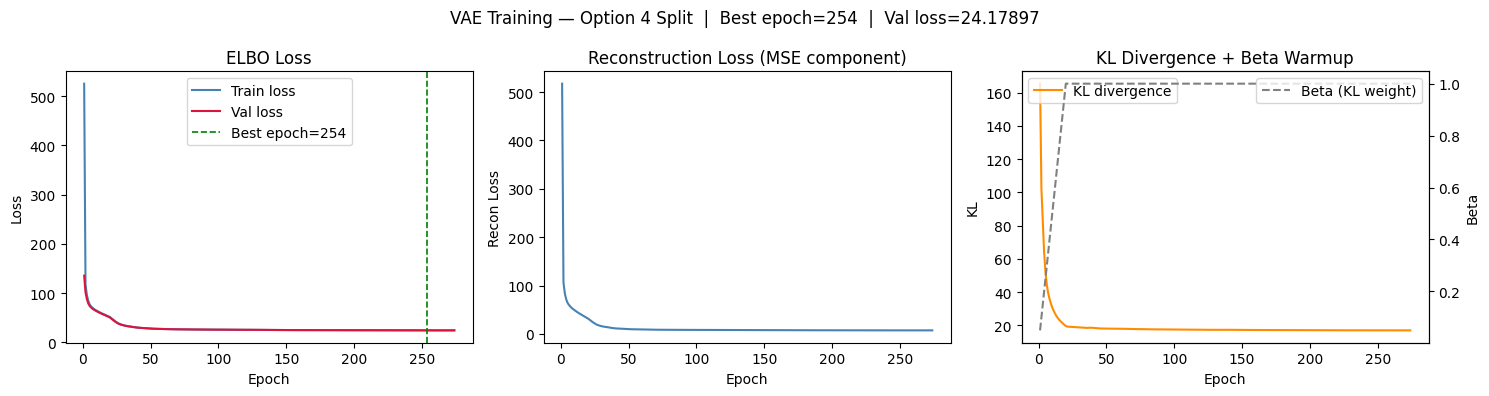

Curves saved to models/vae_v4_training_curves.png


In [12]:
epochs_ran = len(history['train_loss'])
ep         = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curves
axes[0].plot(ep, history['train_loss'], label='Train loss',  color='steelblue')
axes[0].plot(ep, history['val_loss'],   label='Val loss',    color='crimson')
axes[0].axvline(best_epoch, color='green', linestyle='--', linewidth=1.2,
                label=f'Best epoch={best_epoch}')
axes[0].set_title('ELBO Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Reconstruction loss
axes[1].plot(ep, history['train_recon'], color='steelblue')
axes[1].set_title('Reconstruction Loss (MSE component)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Recon Loss')

# KL divergence
ax2 = axes[2].twinx()
axes[2].plot(ep, history['train_kl'], color='darkorange', label='KL divergence')
ax2.plot(ep, history['beta'],         color='gray', linestyle='--', label='Beta (KL weight)')
axes[2].set_title('KL Divergence + Beta Warmup')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL')
ax2.set_ylabel('Beta')
axes[2].legend(loc='upper left')
ax2.legend(loc='upper right')

plt.suptitle(f'VAE Training — Option 4 Split  |  Best epoch={best_epoch}  |  Val loss={best_val_loss:.5f}',
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'vae_v4_training_curves.png'), dpi=100)
plt.show()
print('Curves saved to models/vae_v4_training_curves.png')

---
## Part 5 — Overfitting Check

Three checks:  
1. **MSE gap** between train and val reconstruction scores  
2. **Loss divergence** in final 10 epochs (val rising while train falling?)  
3. **KS test** — are train and val MSE distributions statistically similar?

OVERFITTING CHECK

  Train MSE mean : 0.081384
  Val   MSE mean : 0.081348
  Gap            : 0.04%

  KS statistic   : 0.0186
  KS p-value     : 0.3527
  Same distribution? : YES

  Final 10 epochs diverging? : False

VERDICT:
  [GOOD]  Gap < 20% and no divergence — model is NOT overfitting.


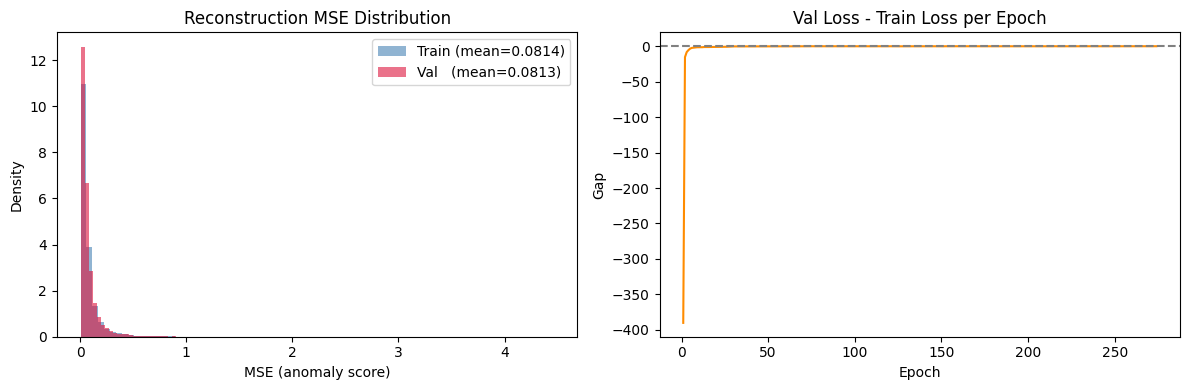

In [13]:
from scipy import stats

# Compute per-window MSE on train and val sets
train_mse = vae.anomaly_score(X_train)
val_mse   = vae.anomaly_score(X_val)

train_mean = train_mse.mean()
val_mean   = val_mse.mean()
gap_pct    = abs(val_mean - train_mean) / train_mean * 100

# KS test on a sample
sample_size = min(5000, len(train_mse), len(val_mse))
ks_stat, ks_pval = stats.ks_2samp(
    train_mse[:sample_size],
    val_mse[:sample_size]
)

# Check if val loss diverging in final 10 epochs
train_tail = np.array(history['train_loss'][-10:])
val_tail   = np.array(history['val_loss'][-10:])
diverging  = (np.all(np.diff(val_tail) > 0) and np.all(np.diff(train_tail) < 0))

print('=' * 60)
print('OVERFITTING CHECK')
print('=' * 60)
print()
print(f'  Train MSE mean : {train_mean:.6f}')
print(f'  Val   MSE mean : {val_mean:.6f}')
print(f'  Gap            : {gap_pct:.2f}%')
print()
print(f'  KS statistic   : {ks_stat:.4f}')
print(f'  KS p-value     : {ks_pval:.4f}')
print(f'  Same distribution? : {"YES" if ks_pval > 0.05 else "NO — distributions differ"}')
print()
print(f'  Final 10 epochs diverging? : {diverging}')
print()

# Verdict
print('VERDICT:')
if gap_pct < 20 and not diverging:
    print('  [GOOD]  Gap < 20% and no divergence — model is NOT overfitting.')
elif gap_pct < 50 and not diverging:
    print('  [OK]    Gap 20-50% but no divergence — mild gap, likely due to')
    print('          distribution shift between train/val cases, not overfitting.')
elif diverging:
    print('  [WARN]  Val loss diverging from train — overfitting detected.')
    print('          Consider reducing EPOCHS or increasing dropout/regularization.')
else:
    print('  [INFO]  Large gap but no divergence. Check if train/val are from')
    print('          different Kubernetes cases (expected distribution shift).')

# MSE distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_mse, bins=80, alpha=0.6, color='steelblue', label=f'Train (mean={train_mean:.4f})', density=True)
axes[0].hist(val_mse,   bins=80, alpha=0.6, color='crimson',   label=f'Val   (mean={val_mean:.4f})',   density=True)
axes[0].set_title('Reconstruction MSE Distribution')
axes[0].set_xlabel('MSE (anomaly score)')
axes[0].set_ylabel('Density')
axes[0].legend()

gap_per_epoch = [v - t for t, v in zip(history['train_loss'], history['val_loss'])]
axes[1].plot(range(1, len(gap_per_epoch) + 1), gap_per_epoch, color='darkorange')
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title('Val Loss - Train Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Gap')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'vae_v4_overfitting_check.png'), dpi=100)
plt.show()

---
## Part 6 — Save Model

In [14]:
# Compute training set statistics for threshold calibration
train_mse_mean = float(train_mse.mean())
train_mse_std  = float(train_mse.std())

save_data = {
    'weights'    : {k: v.copy() for k, v in vae._param_dict().items()},
    'config'     : {'D': INPUT_DIM, 'H1': HIDDEN1, 'H2': HIDDEN2, 'Z': LATENT_DIM},
    'train_stats': {
        'n_train'       : len(X_train),
        'train_mse_mean': train_mse_mean,
        'train_mse_std' : train_mse_std,
        'best_epoch'    : best_epoch,
        'best_val_loss' : float(best_val_loss),
    },
    'history'    : history,
    'split'      : 'option_4_memory_delta',
}

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(save_data, f)

size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)

print('=' * 55)
print('MODEL SAVED')
print('=' * 55)
print(f'  Path            : {MODEL_PATH}')
print(f'  File size       : {size_mb:.2f} MB')
print(f'  Architecture    : {INPUT_DIM}->64->32->z(16)->32->64->{INPUT_DIM}')
print(f'  Trained on      : {len(X_train):,} normal windows (Option 4)')
print(f'  Best epoch      : {best_epoch}')
print(f'  Best val loss   : {best_val_loss:.5f}')
print(f'  Train MSE mean  : {train_mse_mean:.6f}')
print(f'  Train MSE std   : {train_mse_std:.6f}')
print()
print('Next step: run vae_eval_v4.ipynb for threshold tuning and full evaluation.')

MODEL SAVED
  Path            : c:\Users\jthar\Documents\Claude\Projects\module3\models\vae_v4.pkl
  File size       : 0.10 MB
  Architecture    : 31->64->32->z(16)->32->64->31
  Trained on      : 246,594 normal windows (Option 4)
  Best epoch      : 254
  Best val loss   : 24.17897
  Train MSE mean  : 0.081384
  Train MSE std   : 0.138827

Next step: run vae_eval_v4.ipynb for threshold tuning and full evaluation.
